In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay,precision_recall_curve
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score

df = pd.read_csv('high_risk_pregnancy_realistic_2000 (1).csv')

In [21]:
import joblib

x_train_smote = joblib.load('x_train_smote.pkl')
y_train_smote = joblib.load('y_train_smote.pkl')
x_test_scaled = joblib.load('x_test_scaled.pkl')
y_test        = joblib.load('y_test.pkl')

In [22]:
model=LogisticRegression(max_iter=1000,random_state=20)

In [23]:
model.fit(x_train_smote,y_train_smote)
print("Trained Successfully")

Trained Successfully


In [24]:
y_pred=model.predict(x_test_scaled)
print(y_pred)

[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0
 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1
 1 0 0 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0
 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 1 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1
 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0
 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1]


In [25]:
y_prob= model.predict_proba(x_test_smote)[:, 1]
print(y_prob)

[0.37078409 0.02464841 0.18223882 0.10698878 0.4512255  0.23846827
 0.11769076 0.21265433 0.39550182 0.28769763 0.53337473 0.24870866
 0.16046562 0.28429412 0.42330166 0.12743535 0.19176714 0.56408737
 0.07849779 0.29340397 0.30939074 0.17280726 0.47163453 0.24039998
 0.56970773 0.11433943 0.33190862 0.16314082 0.01576391 0.68827477
 0.37235059 0.43026743 0.13039035 0.60998064 0.20431257 0.04951806
 0.02024369 0.0666687  0.15619803 0.34850974 0.67547107 0.0604785
 0.19491123 0.42395587 0.13594524 0.01513024 0.02394787 0.29767244
 0.16748692 0.31331843 0.03966267 0.1581339  0.06807193 0.30080967
 0.28595305 0.3422963  0.46972807 0.60622232 0.48584108 0.24853783
 0.13193882 0.45992252 0.09262298 0.34849839 0.09206318 0.3212682
 0.18358803 0.81114949 0.24357887 0.2208011  0.1925919  0.6258468
 0.44845413 0.09691961 0.50107696 0.53522421 0.26096167 0.23339278
 0.22755908 0.22177547 0.46469814 0.30168526 0.10429211 0.04360496
 0.43177024 0.61396791 0.35034322 0.13892072 0.66215382 0.1440237

In [26]:
print('Accuracy:', accuracy_score(y_test, y_pred)) #  accuracy of this model is 80%

Accuracy: 0.8045112781954887


In [27]:
print("Classification Report\n")

print(classification_report(y_test, y_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.90      0.88       330
           1       0.42      0.36      0.39        69

    accuracy                           0.80       399
   macro avg       0.65      0.63      0.64       399
weighted avg       0.79      0.80      0.80       399



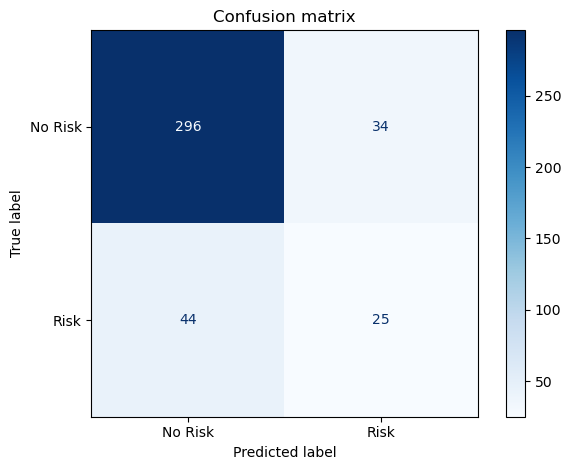

In [28]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=['No Risk','Risk'],cmap='Blues')
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

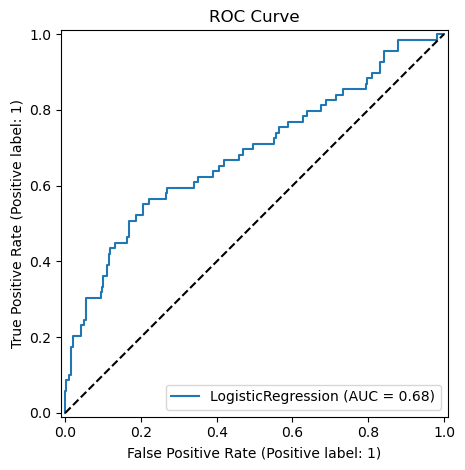

In [29]:
RocCurveDisplay.from_estimator(model, x_test_scaled, y_test)
plt.title('ROC Curve')
plt.plot([0,1],[0,1],'k--')
plt.tight_layout()
plt.show()

In [30]:
print('ROC-AUC Score:', roc_auc_score(y_test, y_prob).round(4))

ValueError: Found input variables with inconsistent numbers of samples: [399, 660]

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {
    'C': [0.01, 0.1, 1, 10, 100],     # model ki freedom — 5 values try hongi
    'penalty': ['l1', 'l2'],          # l1=features hatao, l2=weights chhhote karo
    'solver': ['liblinear']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params,
    cv=5,                    #every combination is tried 5 times
    scoring='roc_auc',
    verbose=1                # show training progress on screen
)

grid.fit(x_train_smote, y_train_smote)
# actual training — 50 experiments happen here (10 combinations x 5 folds)

print('Best Parameters:', grid.best_params_)
print('Best AUC Score:', grid.best_score_.round(4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best AUC Score: 0.883


In [13]:
best_model = grid.best_estimator_    # automatically select the best model

y_pred_tuned = best_model.predict(x_test_scaled)
y_prob_tuned = best_model.predict_proba(x_test_scaled)[:, 1]

print('Accuracy after tuning:', round(accuracy_score(y_test, y_pred_tuned), 4))
print('AUC after tuning:', round(roc_auc_score(y_test, y_prob_tuned), 4))

Accuracy after tuning: 0.8045
AUC after tuning: 0.6848


In [14]:
print('===== BEFORE TUNING =====')
print('AUC :', roc_auc_score(y_test, y_prob).round(4))   

print('\n===== AFTER TUNING =====')
print('AUC :', roc_auc_score(y_test, y_prob_tuned).round(4))

===== BEFORE TUNING =====
AUC : 0.6847

===== AFTER TUNING =====
AUC : 0.6848


In [15]:
print("Classification Report\n")

print(classification_report(y_test, y_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.90      0.88       330
           1       0.42      0.36      0.39        69

    accuracy                           0.80       399
   macro avg       0.65      0.63      0.64       399
weighted avg       0.79      0.80      0.80       399



In [18]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_tuned)

print("\n===== THRESHOLD COMPARISON =====")
for t in [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2]:
    y_pred_t = (y_prob_tuned >= t).astype(int)
    print(f"\n--- Threshold = {t} ---")
    print(classification_report(y_test, y_pred_t))


NameError: name 'precision_recall_curve' is not defined

In [16]:
joblib.dump(best_model, 'logistic_model.pkl')
print("Model saved!")

Model saved!


In [17]:
print(df.columns.tolist())

['timestamp', 'patient_id', 'device_source', 'village', 'age_years', 'gravida_G', 'para_P', 'live_child_L', 'abortion_A', 'death_D', 'gestational_age_weeks', 'systolic_bp_mmHg', 'diastolic_bp_mmHg', 'random_blood_sugar_mg_dL', 'body_temperature_F', 'heart_rate_bpm', 'hemoglobin_g_dL', 'hba1c_percent', 'respiratory_rate_bpm', 'bmi', 'spo2_percent', 'edema_severity', 'symptoms_score_0_10', 'risk_class']


In [18]:
# Preprocessing ke baad feature names save karo
import joblib
joblib.dump(list(x_train_smote.columns) if hasattr(x_train_smote, 'columns') else list(range(x_train_smote.shape[1])), 'feature_names.pkl')
print("Feature names saved!", x_train_smote.shape)

Feature names saved! (2732, 28)


In [20]:
from sklearn.metrics import precision_recall_curve
import pandas as pd

y_probs = best_model.predict_proba(x_test_scaled)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

table = pd.DataFrame({
    'threshold': thresholds,
    'precision': precisions[:-1],
    'recall': recalls[:-1]
})

print(table.round(2))

     threshold  precision  recall
0         0.00       0.17    1.00
1         0.00       0.17    1.00
2         0.00       0.17    1.00
3         0.01       0.17    1.00
4         0.01       0.17    1.00
..         ...        ...     ...
394       0.74       0.80    0.06
395       0.81       1.00    0.06
396       0.81       1.00    0.04
397       0.88       1.00    0.03
398       0.90       1.00    0.01

[399 rows x 3 columns]


In [21]:
# Wo threshold dhoondo jaha recall kam se kam 0.85 ho, aur precision bhi best ho us range mein
target_recall = 0.85
candidates = table[table['recall'] >= target_recall]
print(candidates.tail(15))   # highest thresholds dikhega jo abhi bhi 0.85+ recall de rahe hain

     threshold  precision    recall
91    0.128992   0.191558  0.855072
92    0.129259   0.192182  0.855072
93    0.129422   0.192810  0.855072
94    0.130682   0.193443  0.855072
95    0.131562   0.194079  0.855072
96    0.132216   0.194719  0.855072
97    0.133392   0.195364  0.855072
98    0.133920   0.196013  0.855072
99    0.133941   0.196667  0.855072
100   0.135110   0.197324  0.855072
101   0.135940   0.197987  0.855072
102   0.137735   0.198653  0.855072
103   0.137997   0.199324  0.855072
104   0.139440   0.200000  0.855072
105   0.140632   0.200680  0.855072


In [17]:
import joblib

# Save the fitted scaler (isko missing tha!)
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved!")

# Train medians bhi save karo agar already nahi kiye
joblib.dump(train_medians, 'train_medians.pkl')
print("Medians saved!")

# Village columns (one-hot) bhi save karo — new input ko match karne ke liye
village_columns = [col for col in x_train.columns if col.startswith('village_')]
joblib.dump(village_columns, 'village_columns.pkl')
print("Village columns saved!", village_columns)

NameError: name 'scaler' is not defined